In [1]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_percentage_error

In [2]:
df = pd.read_csv("cleaned_residential_single_family_preprocessed.csv")

df.head()

,CloseDate,CloseMonth,ClosePrice,LivingArea,Bedrooms,Bathrooms,LotSize,LivingArea_missing,Bedrooms_missing,Bathrooms_missing,LotSize_missing
0,2022-01-01,2022-01,535000.0,2061.0,4.0,2.0,12232.0,0,0,0,0
1,2022-01-01,2022-01,560000.0,1546.0,3.0,2.0,27225.0,0,0,0,0
2,2022-01-02,2022-01,3300000.0,3085.0,3.0,3.0,42237.0,0,0,0,0
3,2022-01-03,2022-01,1700000.0,2916.0,4.0,3.0,5654.0,0,0,0,0
4,2022-01-03,2022-01,405000.0,1632.0,3.0,2.0,6151.0,0,0,0,0


In [3]:
df.shape

(399155, 11)

In [4]:
df.columns.tolist()

['CloseDate',
 'CloseMonth',
 'ClosePrice',
 'LivingArea',
 'Bedrooms',
 'Bathrooms',
 'LotSize',
 'LivingArea_missing',
 'Bedrooms_missing',
 'Bathrooms_missing',
 'LotSize_missing']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399155 entries, 0 to 399154
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   CloseDate           399155 non-null  object 
 1   CloseMonth          399155 non-null  object 
 2   ClosePrice          399155 non-null  float64
 3   LivingArea          398945 non-null  float64
 4   Bedrooms            399155 non-null  float64
 5   Bathrooms           399080 non-null  float64
 6   LotSize             392329 non-null  float64
 7   LivingArea_missing  399155 non-null  int64  
 8   Bedrooms_missing    399155 non-null  int64  
 9   Bathrooms_missing   399155 non-null  int64  
 10  LotSize_missing     399155 non-null  int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 33.5+ MB


In [6]:
df["CloseDate"] = pd.to_datetime(df["CloseDate"], errors="coerce")

In [7]:
df["CloseMonth"] = df["CloseDate"].dt.to_period("M")

In [8]:
df["CloseMonth"].value_counts().sort_index()

CloseMonth
2022-01     2313
2022-02     1227
2022-03      873
2022-04      408
2022-05      229
2022-06      171
2022-07      100
2022-08       72
2022-09       50
2022-10       38
2022-11       23
2022-12       17
2023-01       12
2023-02       19
2023-03       20
2023-04       80
2023-05     1832
2023-06     8601
2023-07     9888
2023-08    11715
2023-09    10744
2023-10    11033
2023-11     9668
2023-12     9518
2024-01     8322
2024-02     9564
2024-03    11634
2024-04    12745
2024-05    13831
2024-06    12544
2024-07    13378
2024-08    12433
2024-09    10909
2024-10    12347
2024-11    10692
2024-12    10623
2025-01     8144
2025-02     8851
2025-03    10610
2025-04    11880
2025-05    11777
2025-06    11701
2025-07    12114
2025-08    11454
2025-09    11456
2025-10    12029
2025-11     9739
2025-12    10455
2026-01     7490
2026-02     8550
2026-03    11177
2026-04    12031
2026-05    12024
Freq: M, Name: count, dtype: int64

In [9]:
target = "ClosePrice"

numeric_features = [
    "LivingArea",
    "Bedrooms",
    "Bathrooms",
    "LotSize",
    "LivingArea_missing",
    "Bedrooms_missing",
    "Bathrooms_missing",
    "LotSize_missing"
]

In [10]:
for col in [target] + numeric_features:
    print(col, col in df.columns)

ClosePrice True
LivingArea True
Bedrooms True
Bathrooms True
LotSize True
LivingArea_missing True
Bedrooms_missing True
Bathrooms_missing True
LotSize_missing True


In [11]:
model_df = df.dropna(subset=["CloseDate", "ClosePrice"]).copy()

model_df = model_df.sort_values("CloseDate").reset_index(drop=True)

model_df.shape

(399155, 11)

In [12]:
all_months = sorted(model_df["CloseMonth"].dropna().unique())
all_months

[Period('2022-01', 'M'),
 Period('2022-02', 'M'),
 Period('2022-03', 'M'),
 Period('2022-04', 'M'),
 Period('2022-05', 'M'),
 Period('2022-06', 'M'),
 Period('2022-07', 'M'),
 Period('2022-08', 'M'),
 Period('2022-09', 'M'),
 Period('2022-10', 'M'),
 Period('2022-11', 'M'),
 Period('2022-12', 'M'),
 Period('2023-01', 'M'),
 Period('2023-02', 'M'),
 Period('2023-03', 'M'),
 Period('2023-04', 'M'),
 Period('2023-05', 'M'),
 Period('2023-06', 'M'),
 Period('2023-07', 'M'),
 Period('2023-08', 'M'),
 Period('2023-09', 'M'),
 Period('2023-10', 'M'),
 Period('2023-11', 'M'),
 Period('2023-12', 'M'),
 Period('2024-01', 'M'),
 Period('2024-02', 'M'),
 Period('2024-03', 'M'),
 Period('2024-04', 'M'),
 Period('2024-05', 'M'),
 Period('2024-06', 'M'),
 Period('2024-07', 'M'),
 Period('2024-08', 'M'),
 Period('2024-09', 'M'),
 Period('2024-10', 'M'),
 Period('2024-11', 'M'),
 Period('2024-12', 'M'),
 Period('2025-01', 'M'),
 Period('2025-02', 'M'),
 Period('2025-03', 'M'),
 Period('2025-04', 'M'),


In [13]:
test_month = all_months[-1]
test_month

Period('2026-05', 'M')

In [14]:
test_df = model_df[model_df["CloseMonth"] == test_month].copy()

In [15]:
train_df = model_df[model_df["CloseMonth"] < test_month].copy()

In [16]:
print("Train date range:", train_df["CloseDate"].min(), "to", train_df["CloseDate"].max())
print("Test date range:", test_df["CloseDate"].min(), "to", test_df["CloseDate"].max())

print("Train months:", sorted(train_df["CloseMonth"].unique()))
print("Test month:", test_month)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train date range: 2022-01-01 00:00:00 to 2026-04-30 00:00:00
Test date range: 2026-05-01 00:00:00 to 2026-05-31 00:00:00
Train months: [Period('2022-01', 'M'), Period('2022-02', 'M'), Period('2022-03', 'M'), Period('2022-04', 'M'), Period('2022-05', 'M'), Period('2022-06', 'M'), Period('2022-07', 'M'), Period('2022-08', 'M'), Period('2022-09', 'M'), Period('2022-10', 'M'), Period('2022-11', 'M'), Period('2022-12', 'M'), Period('2023-01', 'M'), Period('2023-02', 'M'), Period('2023-03', 'M'), Period('2023-04', 'M'), Period('2023-05', 'M'), Period('2023-06', 'M'), Period('2023-07', 'M'), Period('2023-08', 'M'), Period('2023-09', 'M'), Period('2023-10', 'M'), Period('2023-11', 'M'), Period('2023-12', 'M'), Period('2024-01', 'M'), Period('2024-02', 'M'), Period('2024-03', 'M'), Period('2024-04', 'M'), Period('2024-05', 'M'), Period('2024-06', 'M'), Period('2024-07', 'M'), Period('2024-08', 'M'), Period('2024-09', 'M'), Period('2024-10', 'M'), Period('2024-11', 'M'), Period('2024-12', 'M'), 

In [18]:
X_train = train_df[numeric_features]
y_train = train_df[target]

X_test = test_df[numeric_features]
y_test = test_df[target]
X_train.head()
y_train.head()

0     535000.0
1     560000.0
2    3300000.0
3    3090000.0
4    2667000.0
Name: ClosePrice, dtype: float64

In [19]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ]
)

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [20]:
baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['LivingArea','Bedrooms','Bathrooms',...,'Bedrooms_missing', 'Bathrooms_missing','LotSize_missing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subse

In [21]:
y_pred = baseline_model.predict(X_test)

In [22]:
r2 = r2_score(y_test, y_pred)
r2

0.20855190291106307

In [23]:
mape = mean_absolute_percentage_error(y_test, y_pred)
mape

0.6712496011889557

In [24]:
absolute_percentage_errors = np.abs((y_test - y_pred) / y_test)
mdape = np.median(absolute_percentage_errors)
mdape

np.float64(0.44681576386340804)

In [25]:
print("Baseline Linear Regression Results")
print("----------------------------------")
print("Test month:", test_month)
print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.4f} ({mape * 100:.2f}%)")
print(f"MdAPE: {mdape:.4f} ({mdape * 100:.2f}%)")

Baseline Linear Regression Results
----------------------------------
Test month: 2026-05
Train rows: 387131
Test rows: 12024
R²: 0.2086
MAPE: 0.6712 (67.12%)
MdAPE: 0.4468 (44.68%)


In [26]:
baseline_results = pd.DataFrame([
    {
        "model": "Linear Regression Baseline",
        "test_month": str(test_month),
        "train_start": train_df["CloseDate"].min(),
        "train_end": train_df["CloseDate"].max(),
        "test_start": test_df["CloseDate"].min(),
        "test_end": test_df["CloseDate"].max(),
        "train_rows": len(train_df),
        "test_rows": len(test_df),
        "features": ", ".join(numeric_features),
        "R2": r2,
        "MAPE": mape,
        "MdAPE": mdape
    }
])

baseline_results

,model,test_month,train_start,train_end,test_start,test_end,train_rows,test_rows,features,R2,MAPE,MdAPE
0,Linear Regression Baseline,2026-05,2022-01-01,2026-04-30,2026-05-01,2026-05-31,387131,12024,"LivingArea, Bedrooms, Bathrooms, LotSize, Livi...",0.208552,0.67125,0.446816


In [27]:
predictions_df = test_df[["CloseDate", "CloseMonth", "ClosePrice"]].copy()
predictions_df["PredictedClosePrice"] = y_pred
predictions_df["AbsoluteError"] = np.abs(predictions_df["ClosePrice"] - predictions_df["PredictedClosePrice"])
predictions_df["AbsolutePercentageError"] = predictions_df["AbsoluteError"] / predictions_df["ClosePrice"]

predictions_df.head()

,CloseDate,CloseMonth,ClosePrice,PredictedClosePrice,AbsoluteError,AbsolutePercentageError
387131,2026-05-01,2026-05,745000.0,8.948336e+05,149833.576162,0.201119
387132,2026-05-01,2026-05,1755000.0,1.551920e+06,203080.468273,0.115715
387133,2026-05-01,2026-05,1660000.0,1.527504e+06,132496.294778,0.079817
387134,2026-05-01,2026-05,963800.0,8.925941e+05,71205.912833,0.073880
387135,2026-05-01,2026-05,523000.0,8.943767e+05,371376.743448,0.710089


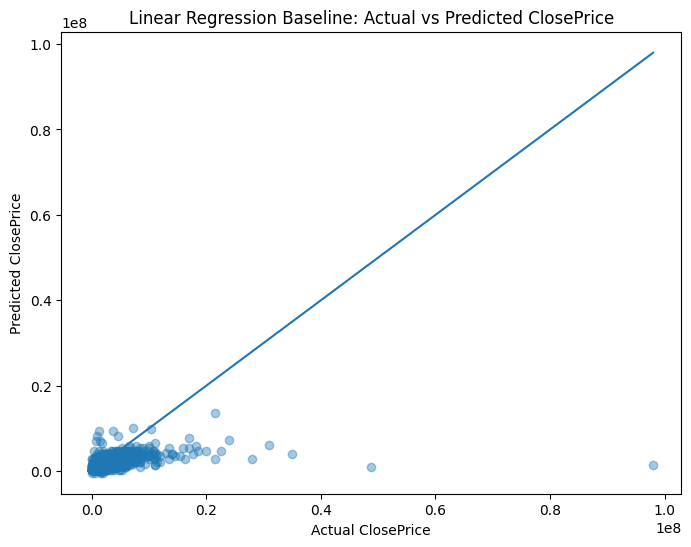

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(predictions_df["ClosePrice"], predictions_df["PredictedClosePrice"], alpha=0.4)
plt.xlabel("Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Linear Regression Baseline: Actual vs Predicted ClosePrice")

min_price = min(predictions_df["ClosePrice"].min(), predictions_df["PredictedClosePrice"].min())
max_price = max(predictions_df["ClosePrice"].max(), predictions_df["PredictedClosePrice"].max())

plt.plot([min_price, max_price], [min_price, max_price])
plt.show()

## Week 4 Baseline Model Summary

For the Week 4 baseline model, I trained a Linear Regression model to predict `ClosePrice`. I used the same chronological evaluation methodology required by the program: the latest full month of available data was used as the test set, and all earlier months were used for training. This prevents data leakage from future sales into the training set.

The baseline feature set includes `LivingArea`, `Bedrooms`, `Bathrooms`, and `LotSize`, along with missing-value indicator columns created during preprocessing. Missing numerical values were handled using median imputation inside the modeling pipeline. I also standardized numerical features before fitting the Linear Regression model.

The model was evaluated on the test month using R², MAPE, and MdAPE. These results serve as the baseline for future modeling iterations. Later models can be compared against this Linear Regression baseline to determine whether added features, different imputation strategies, encoding, feature engineering, or more complex algorithms improve predictive performance.

## Further Thoughts + Baseline Model A: Linear Regression with Raw ClosePrice

For the initial baseline model, I trained a standard Linear Regression model using the raw `ClosePrice` as the target variable. The feature set included the core numeric property attributes from preprocessing: `LivingArea`, `Bedrooms`, `Bathrooms`, and `LotSize`, along with missing-value indicator columns.

This model serves as the simplest benchmark for future experiments. It is intentionally basic so that later changes, such as target transformation, outlier handling, or more robust modeling choices, can be compared against a clear starting point.

The model was evaluated using the standardized chronological split: all months before the latest full month were used for training, and the latest full month was used as the test set. This prevents data leakage and matches the evaluation methodology required by the internship program.

### Baseline Results

- Model: Linear Regression
- Target: Raw `ClosePrice`
- Test month: May 2026
- R²: 0.2086
- MAPE: 67.13%
- MdAPE: 44.68%

The baseline model had limited predictive performance. The actual-versus-predicted plot showed that the model struggled especially with high-priced homes. Many expensive properties were underpredicted, suggesting that the relationship between the current features and price is not fully linear on the raw dollar scale.

## Motivation for Further Improvement

After evaluating the initial Linear Regression baseline, I observed that the model had relatively weak performance, with an R² of approximately 0.21 and high percentage-based errors. The actual-versus-predicted plot showed that the model did not handle expensive homes very well. In particular, many high-value properties were predicted far below their actual sale prices.

This suggested that the first baseline was too simple for the structure of the housing data. Real estate prices are often highly right-skewed, with many moderately priced homes and a smaller number of very expensive homes. These extreme values can strongly influence a standard Linear Regression model and make it harder for the model to fit the majority of the data well.

Because of this, I treated the baseline as a starting point rather than a final model. I continued experimenting with three main improvements:

1. Log-transforming the target variable to reduce price skew.
2. Trimming extreme outliers to test how much they affected model performance.
3. Trying a more robust linear model that is less sensitive to outliers.

Each experiment changes only one major modeling decision at a time, making it easier to understand which changes actually improve R², MAPE, and MdAPE.

## Experiment B: Linear Regression with Log-Transformed ClosePrice

For the second experiment, I transformed the target variable from raw `ClosePrice` to `log_ClosePrice` using `np.log1p(ClosePrice)`. This was motivated by the skewed distribution of housing prices. In the original target scale, very expensive homes can dominate the regression loss because their dollar errors are much larger than errors for typical homes.

A log transformation compresses the scale of high prices and makes the model focus more on relative differences rather than absolute dollar differences. This is especially useful for MAPE and MdAPE, since those metrics evaluate percentage error rather than raw dollar error.

After training on the log-transformed target, I converted predictions back to dollar values using `np.expm1()` before calculating R², MAPE, and MdAPE. This ensures that evaluation is still performed on the original `ClosePrice` scale.

This experiment tests whether Linear Regression performs better when the target distribution is made less skewed.

In [35]:
# Define feature columns for modeling

base_numeric_features = [
    "LivingArea",
    "Bedrooms",
    "Bathrooms",
    "LotSize"
]

for col in base_numeric_features:
    missing_col = f"{col}_missing"
    if missing_col not in model_df.columns:
        model_df[missing_col] = model_df[col].isna().astype(int)

missing_flag_features = [f"{col}_missing" for col in base_numeric_features]

all_features = base_numeric_features + missing_flag_features

all_features

['LivingArea',
 'Bedrooms',
 'Bathrooms',
 'LotSize',
 'LivingArea_missing',
 'Bedrooms_missing',
 'Bathrooms_missing',
 'LotSize_missing']

In [36]:
test_month = sorted(model_df["CloseMonth"].dropna().unique())[-1]

train_df = model_df[model_df["CloseMonth"] < test_month].copy()
test_df = model_df[model_df["CloseMonth"] == test_month].copy()

print("Test month:", test_month)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Test month: 2026-05
Train shape: (387131, 11)
Test shape: (12024, 11)


In [37]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, all_features)
    ]
)

In [38]:
# Experimenting with Log-transformed target

X_train = train_df[all_features]
X_test = test_df[all_features]

y_train_log = np.log1p(train_df["ClosePrice"])
y_test = test_df["ClosePrice"]

log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

log_model.fit(X_train, y_train_log)

log_preds = log_model.predict(X_test)
y_pred_log_model = np.expm1(log_preds)

r2_log = r2_score(y_test, y_pred_log_model)
mape_log = mean_absolute_percentage_error(y_test, y_pred_log_model)
mdape_log = np.median(np.abs((y_test - y_pred_log_model) / y_test))

print("Log-Transformed Target")
print("-----------------------------------")
print(f"R²: {r2_log:.4f}")
print(f"MAPE: {mape_log:.4f} ({mape_log * 100:.2f}%)")
print(f"MdAPE: {mdape_log:.4f} ({mdape_log * 100:.2f}%)")

Log-Transformed Target
-----------------------------------
R²: -1.7003
MAPE: 0.5012 (50.12%)
MdAPE: 0.3661 (36.61%)


### Reasoning

I expected this experiment to improve percentage-based errors because predicting log price is closer to predicting proportional changes in price. Since MAPE and MdAPE measure relative error, a log-transformed target is often better aligned with these evaluation metrics than raw-dollar Linear Regression.

If this model improves MdAPE, it suggests that the original model was being distorted by the skewed price distribution. If R² decreases but MdAPE improves, that still may be useful because the internship program specifically asks us to track both R² and percentage-based error. This doesn't seem to be the case, so further experimentation may help us improve results.

## Experiment: Linear Regression After Trimming Extreme ClosePrice Outliers

For the third experiment, I tested whether extreme sale prices were disproportionately affecting the Linear Regression baseline. Housing datasets often contain unusual transactions, luxury properties, very large lots, or data-entry anomalies. These extreme observations can pull the regression line away from the majority of homes.

To test this, I created a trimmed version of the dataset by removing the bottom 0.5% and top 0.5% of `ClosePrice` values. I treated this as a separate experiment rather than the default preprocessing strategy because expensive homes may be legitimate observations, not errors.

The goal of this experiment is not to hide difficult cases, but to measure how sensitive the baseline model is to extreme target values.

In [40]:
# Trim extreme ClosePrice outliers

lower_price = model_df["ClosePrice"].quantile(0.005)
upper_price = model_df["ClosePrice"].quantile(0.995)

model_df_trimmed = model_df[
    (model_df["ClosePrice"] >= lower_price) &
    (model_df["ClosePrice"] <= upper_price)
].copy()

print("Original rows:", len(model_df))
print("Trimmed rows:", len(model_df_trimmed))
print("Lower cutoff:", lower_price)
print("Upper cutoff:", upper_price)

Original rows: 399155
Trimmed rows: 395167
Lower cutoff: 189000.0
Upper cutoff: 8434139.999999665


In [41]:
# Recreate chronological split on trimmed data

model_df_trimmed["CloseMonth"] = model_df_trimmed["CloseDate"].dt.to_period("M")

test_df_trimmed = model_df_trimmed[model_df_trimmed["CloseMonth"] == test_month].copy()
train_df_trimmed = model_df_trimmed[model_df_trimmed["CloseMonth"] < test_month].copy()

print("Trimmed train shape:", train_df_trimmed.shape)
print("Trimmed test shape:", test_df_trimmed.shape)

Trimmed train shape: (383263, 11)
Trimmed test shape: (11904, 11)


In [42]:
X_train_trimmed = train_df_trimmed[all_features]
y_train_trimmed = train_df_trimmed["ClosePrice"]

X_test_trimmed = test_df_trimmed[all_features]
y_test_trimmed = test_df_trimmed["ClosePrice"]

trimmed_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

trimmed_model.fit(X_train_trimmed, y_train_trimmed)

y_pred_trimmed = trimmed_model.predict(X_test_trimmed)

r2_trimmed = r2_score(y_test_trimmed, y_pred_trimmed)
mape_trimmed = mean_absolute_percentage_error(y_test_trimmed, y_pred_trimmed)
mdape_trimmed = np.median(np.abs((y_test_trimmed - y_pred_trimmed) / y_test_trimmed))

print("Experiment: Trimmed Outliers")
print("------------------------------")
print(f"R²: {r2_trimmed:.4f}")
print(f"MAPE: {mape_trimmed:.4f} ({mape_trimmed * 100:.2f}%)")
print(f"MdAPE: {mdape_trimmed:.4f} ({mdape_trimmed * 100:.2f}%)")

Experiment: Trimmed Outliers
------------------------------
R²: 0.3063
MAPE: 0.5633 (56.33%)
MdAPE: 0.3960 (39.60%)


### Reasoning

This experiment helps determine whether the baseline model's poor performance is mainly caused by a small number of extreme sales. If trimming improves R², MAPE, or MdAPE substantially, then outliers are likely having a major effect on the model. I observed this was not the case, so trimming the dataset is not a substantial improvement to my original approach.

However, I would be cautious about using this as the final modeling approach because high-priced homes may be valid examples that the model should eventually learn to handle. Trimming is useful diagnostically, but it changes the prediction problem by removing the extreme observations.

## Robust Linear Model

For the fourth experiment, I tested a more robust linear model. Standard Linear Regression minimizes squared error, which means very large errors receive disproportionately large penalties. As a result, outliers can strongly influence the fitted coefficients.

A robust linear model is designed to reduce the influence of extreme observations. Instead of allowing a few unusual properties to dominate the model, it fits a relationship that is more stable for the majority of the dataset.

This experiment keeps the same chronological train/test split and the same feature set, but changes the model type from standard Linear Regression to a robust linear alternative.

In [43]:
from sklearn.linear_model import HuberRegressor

robust_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", HuberRegressor(max_iter=1000))
])

X_train = train_df[all_features]
y_train = train_df["ClosePrice"]

X_test = test_df[all_features]
y_test = test_df["ClosePrice"]

robust_model.fit(X_train, y_train)

y_pred_robust = robust_model.predict(X_test)

r2_robust = r2_score(y_test, y_pred_robust)
mape_robust = mean_absolute_percentage_error(y_test, y_pred_robust)
mdape_robust = np.median(np.abs((y_test - y_pred_robust) / y_test))

print("Experiment: Robust Linear Model")
print("---------------------------------")
print(f"R²: {r2_robust:.4f}")
print(f"MAPE: {mape_robust:.4f} ({mape_robust * 100:.2f}%)")
print(f"MdAPE: {mdape_robust:.4f} ({mdape_robust * 100:.2f}%)")

Experiment: Robust Linear Model
---------------------------------
R²: 0.2159
MAPE: 0.5132 (51.32%)
MdAPE: 0.3663 (36.63%)


### Reasoning

I tried a robust linear model because the baseline results suggested that the model was sensitive to unusual high-priced properties. A robust model is still interpretable as a linear model, but it is less affected by extreme errors than ordinary least squares regression.

If this model improves MdAPE or MAPE, it suggests that reducing the influence of outliers helps the model make more typical predictions. If it lowers R², that may mean the model is fitting the majority of homes better while fitting extreme homes worse. This tradeoff is important to document because R² and percentage-error metrics may reward different behavior.

In [44]:
experiment_results = pd.DataFrame([
    {
        "experiment": "A",
        "model": "Linear Regression",
        "target": "Raw ClosePrice",
        "data": "Full data",
        "R2": r2,
        "MAPE": mape,
        "MdAPE": mdape
    },
    {
        "experiment": "B",
        "model": "Linear Regression",
        "target": "Log ClosePrice",
        "data": "Full data",
        "R2": r2_log,
        "MAPE": mape_log,
        "MdAPE": mdape_log
    },
    {
        "experiment": "C",
        "model": "Linear Regression",
        "target": "Raw ClosePrice",
        "data": "Trimmed 1st-99th percentile",
        "R2": r2_trimmed,
        "MAPE": mape_trimmed,
        "MdAPE": mdape_trimmed
    },
    {
        "experiment": "D",
        "model": "Huber Regressor",
        "target": "Raw ClosePrice",
        "data": "Full data",
        "R2": r2_robust,
        "MAPE": mape_robust,
        "MdAPE": mdape_robust
    }
])

experiment_results.sort_values("MdAPE")

,experiment,model,target,data,R2,MAPE,MdAPE
1,B,Linear Regression,Log ClosePrice,Full data,-1.700268,0.501228,0.366083
3,D,Huber Regressor,Raw ClosePrice,Full data,0.215917,0.513152,0.366298
2,C,Linear Regression,Raw ClosePrice,Trimmed 1st-99th percentile,0.306321,0.563250,0.395951
0,A,Linear Regression,Raw ClosePrice,Full data,0.208552,0.671250,0.446816


In [45]:
experiment_results.to_csv("baseline_model_experiment_results.csv", index=False)

## Final Baseline Modeling Summary

In this notebook, I trained an initial Linear Regression baseline model and evaluated it using the standardized chronological train/test split. The latest full month, May 2026, was used as the test set, and all earlier months were used for training. This avoids data leakage and keeps the evaluation methodology consistent with the internship program requirements.

The initial Linear Regression baseline used raw `ClosePrice` as the target and included core numeric property features: `LivingArea`, `Bedrooms`, `Bathrooms`, and `LotSize`, plus missing-value indicators. The baseline achieved an R² of approximately 0.21, with high MAPE and MdAPE. The actual-versus-predicted plot showed that the model struggled especially with high-priced homes.

Because of this, I treated the baseline as the first experiment rather than the final model. I tested a few follow-up changes:

1. **Log-transforming the target** to reduce the effect of right-skewed price values and better align the model with percentage-based error metrics.
2. **Trimming extreme outliers** to test whether unusually low or high sale prices were disproportionately affecting the regression fit.
3. **Using a robust linear model** to reduce the influence of extreme observations while keeping the model relatively interpretable.

My original Linear Regression baseline underpredicted many expensive homes, so I chose these experiments to better investigate whether the issue was caused by skewness, outlier sensitivity, or the limitations of a simple linear relationship. These experiments helped clarify that model performance depends not only on the algorithm, but also on how the target distribution and outliers are handled. The results from these experiments provide a stronger baseline for future modeling iterations, where I can add location features, engineer new variables, and test more flexible models.